<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/06_Hernandez_Alvaro_TransferenciaAprendizajeRNR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tarea sobre transferencia de aprendizaje con RNN**

* Asignatura: Redes Neuronales Profundas
* Profesor: Dr. José David Díaz Román
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 20 de marzo de 2026




## **Parte 1 – Reproducción del experimento base**

1. Descargar el archivo sentiment140-subset.csv y glove.6B.100d.txt (https://nlp.stanford.edu/projects/glove/).
2. Ejecutar el código proporcionado (modelo A y modelo B).
3. Comparar los resultados de exactitud y pérdida en entrenamiento y validación.
4. Graficar las curvas accuracy y loss de ambos modelos.
5. Contestar:
    * ¿Qué diferencias observas entre el entrenamiento desde cero y el uso de embeddings preentrenados?
    * ¿Cuál converge más rápido?
    * ¿Cuál generaliza mejor (mejor desempeño en validación)?


In [4]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import GRU, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
# Definimos la ruta del archivo y cargamos el conjunto de datos
path_file = "/content/drive/MyDrive/ClassFiles/sentiment140-subset.csv"
dataset1 = pd.read_csv(path_file)
display(dataset1.head())

,polarity,text
0,0,@kconsidder You never tweet
1,0,Sick today coding from the couch.
2,1,"@ChargerJenn Thx for answering so quick,I was ..."
3,1,Wii fit says I've lost 10 pounds since last ti...
4,0,@MrKinetik Not a thing!!! I don't really have...


In [6]:
# Extraemos textos y etiquetas (usando dataset1)
texts = dataset1["text"].astype(str).values
labels = dataset1["polarity"].values

In [7]:
# Configuramos y aplicamos la tokenización a los textos
print("Tokenizando...")
VOCAB_SIZE = 10000
MAX_LEN = 40
tokenizer = Tokenizer(num_words=VOCAB_SIZE, filters='!"$%&()*+,-./:;<=>?[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(texts)

# Convertimos los textos a secuencias numéricas y aplicamos el padding
X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, maxlen=MAX_LEN, padding="post")
y = np.array(labels)

# Dividimos los datos en conjuntos de entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

Tokenizando...


In [8]:
# Configuramos el mecanismo de parada temprana para evitar el sobreajuste
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Construimos el Modelo A con una capa de Embedding inicializada desde cero
print("Entrenando Modelo A (Desde cero)...")
embed_dim = 100
model_a = keras.Sequential([
    layers.Input(shape=(MAX_LEN,), dtype='int32'),
    layers.Embedding(VOCAB_SIZE, embed_dim),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(1, activation="sigmoid")
])

# Compilamos la arquitectura especificando el optimizador y las métricas
model_a.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_a.summary()

# Entrenamos el Modelo A aplicando las 100 épocas límite y el callback establecido
hist_a = model_a.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=2,
    callbacks=[early_stopping]
)

Entrenando Modelo A (Desde cero)...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,609 (4.14 MB)

 Trainable params: 1,084,609 (4.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6641/6641 - 70s - 10ms/step - accuracy: 0.7947 - loss: 0.4390 - val_accuracy: 0.8100 - val_loss: 0.4182
Epoch 2/100
6641/6641 - 73s - 11ms/step - accuracy: 0.8224 - loss: 0.3907 - val_accuracy: 0.8148 - val_loss: 0.4063
Epoch 3/100
6641/6641 - 60s - 9ms/step - accuracy: 0.8358 - loss: 0.3651 - val_accuracy: 0.8160 - val_loss: 0.4070
Epoch 4/100
6641/6641 - 59s - 9ms/step - accuracy: 0.8488 - loss: 0.3413 - val_accuracy: 0.8137 - val_loss: 0.4166
Epoch 5/100
6641/6641 - 81s - 12ms/step - accuracy: 0.8615 - loss: 0.3160 - val_accuracy: 0.8093 - val_loss: 0.4298


In [9]:
print("Cargando embeddings GloVe...")

# Definimos la ruta del archivo GloVe
glove_path = "/content/drive/MyDrive/ClassFiles/glove.6B.100d.txt"

embeddings_index = {}

# Leemos el archivo y almacenamos los coeficientes de las palabras
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word, coefs = values[0], np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

# Preparamos la matriz de embeddings con ceros
embedding_matrix = np.zeros((VOCAB_SIZE, 100))

# Asignamos los vectores correspondientes a las palabras de nuestro vocabulario
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

# Construimos el Modelo B con la capa de Embedding preentrenada y congelada
print("Entrenando Modelo B (LSTM + GloVe)...")
model_b = keras.Sequential([
    layers.Input(shape=(MAX_LEN,), dtype='int32'),
    layers.Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix], trainable=False),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dense(1, activation="sigmoid")
])

# Compilamos la arquitectura del Modelo B
model_b.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_b.summary()

# Entrenamos el Modelo B aplicando parada temprana
hist_b = model_b.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=2,
    callbacks=[early_stopping]
)

Cargando embeddings GloVe...
Entrenando Modelo B (LSTM + GloVe)...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 40, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,084,609 (4.14 MB)

 Trainable params: 84,609 (330.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/100
6641/6641 - 58s - 9ms/step - accuracy: 0.7553 - loss: 0.4980 - val_accuracy: 0.7806 - val_loss: 0.4665
Epoch 2/100
6641/6641 - 56s - 8ms/step - accuracy: 0.7893 - loss: 0.4471 - val_accuracy: 0.7910 - val_loss: 0.4467
Epoch 3/100
6641/6641 - 56s - 8ms/step - accuracy: 0.8001 - loss: 0.4284 - val_accuracy: 0.7969 - val_loss: 0.4368


## **Parte 2: Modificación de la arquitectura.**

1. Cambiar la arquitectura:
* Reemplazar Bidirectional(LSTM(64)) por Bidirectional(GRU(64)) y comparar. Además, agregar una capa Dropout(0.5) después de la capa recurrente. Comparar resultados.
2. Evaluar con métricas adicionales:
* Generar y analizar una matriz de confusión.
* Calcular precisión, recall y F1-score.
3. Prueba con nuevas oraciones:
* Crear un bloque de código para predecir el sentimiento de frases como:

```
"I really loved this trip!",

"This was a terrible experience.",

"My sister is afraid of going to the dentist.", etc.
```



In [10]:
# Construimos el Modelo GRU incorporando regularización mediante Dropout
print("Entrenando Modelo GRU (GRU + Dropout + GloVe)...")
model_gru = keras.Sequential([
    layers.Input(shape=(MAX_LEN,), dtype='int32'),
    layers.Embedding(VOCAB_SIZE, 100, weights=[embedding_matrix], trainable=False),
    layers.Bidirectional(GRU(64)),
    Dropout(0.5), # Capa de regularización con la coma corregida
    layers.Dense(1, activation="sigmoid")
])

# Compilamos la arquitectura del Modelo GRU
model_gru.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_gru.summary()

# Entrenamos el Modelo GRU aplicando parada temprana
hist_gru = model_gru.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=100,
    batch_size=64,
    verbose=2,
    callbacks=[early_stopping]
)

Entrenando Modelo GRU (GRU + Dropout + GloVe)...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 40, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        63,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,063,873 (4.06 MB)

 Trainable params: 63,873 (249.50 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

Epoch 1/100
6641/6641 - 59s - 9ms/step - accuracy: 0.7513 - loss: 0.5067 - val_accuracy: 0.7782 - val_loss: 0.4680
Epoch 2/100
6641/6641 - 56s - 8ms/step - accuracy: 0.7812 - loss: 0.4636 - val_accuracy: 0.7853 - val_loss: 0.4545
Epoch 3/100
6641/6641 - 56s - 9ms/step - accuracy: 0.7906 - loss: 0.4493 - val_accuracy: 0.7909 - val_loss: 0.4464


## Comparación del modelo B (LSTM+GloVw) con el Modelo GRU con Dropout

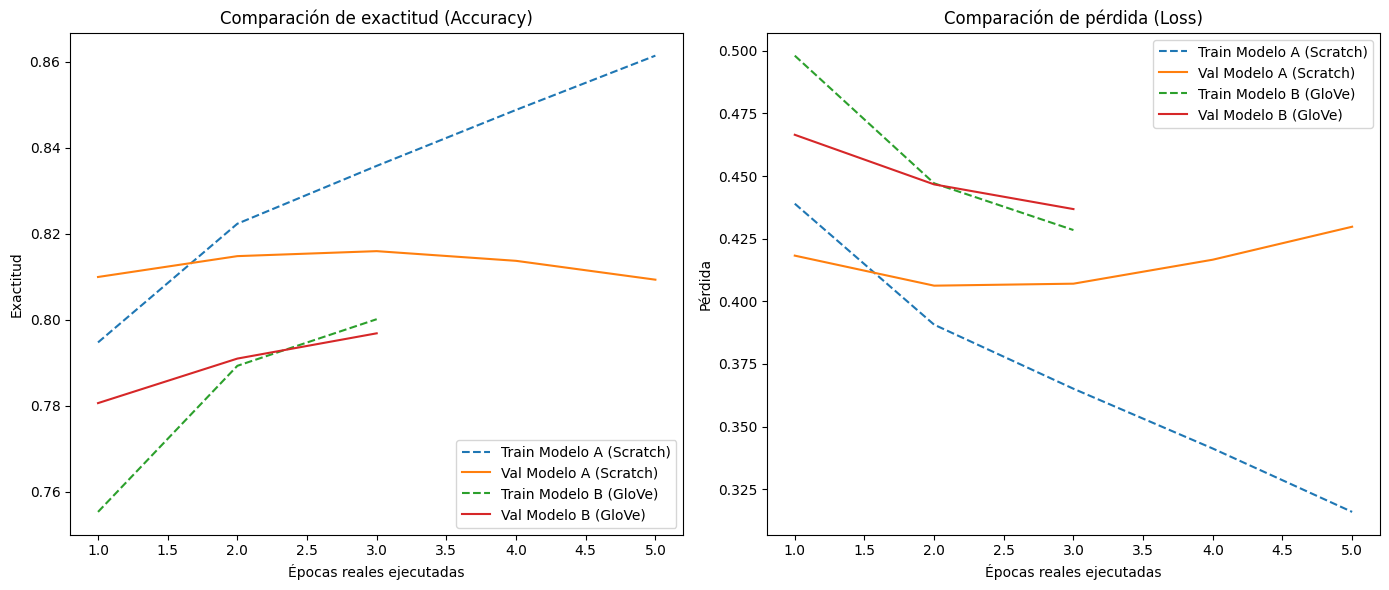

In [11]:
# Extraemos el historial de métricas para generar las gráficas comparativas
acc_a = hist_a.history['accuracy']
val_acc_a = hist_a.history['val_accuracy']
loss_a = hist_a.history['loss']
val_loss_a = hist_a.history['val_loss']

acc_b = hist_b.history['accuracy']
val_acc_b = hist_b.history['val_accuracy']
loss_b = hist_b.history['loss']
val_loss_b = hist_b.history['val_loss']

# Ajustamos el rango de épocas basándonos en la duración real del entrenamiento de cada modelo
epochs_range_a = range(1, len(acc_a) + 1)
epochs_range_b = range(1, len(acc_b) + 1)

plt.figure(figsize=(14, 6))

# Generamos la gráfica de exactitud (accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range_a, acc_a, label='Train Modelo A (Scratch)', linestyle='--')
plt.plot(epochs_range_a, val_acc_a, label='Val Modelo A (Scratch)')
plt.plot(epochs_range_b, acc_b, label='Train Modelo B (GloVe)', linestyle='--')
plt.plot(epochs_range_b, val_acc_b, label='Val Modelo B (GloVe)')
plt.legend(loc='lower right')
plt.title('Comparación de exactitud (Accuracy)')
plt.xlabel('Épocas reales ejecutadas')
plt.ylabel('Exactitud')

# Generamos la gráfica de pérdida (loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range_a, loss_a, label='Train Modelo A (Scratch)', linestyle='--')
plt.plot(epochs_range_a, val_loss_a, label='Val Modelo A (Scratch)')
plt.plot(epochs_range_b, loss_b, label='Train Modelo B (GloVe)', linestyle='--')
plt.plot(epochs_range_b, val_loss_b, label='Val Modelo B (GloVe)')
plt.legend(loc='upper right')
plt.title('Comparación de pérdida (Loss)')
plt.xlabel('Épocas reales ejecutadas')
plt.ylabel('Pérdida')

plt.tight_layout()
plt.show()

In [12]:
# Comparamos numéricamente los resultados finales obtenidos al detenerse el entrenamiento
resultados = pd.DataFrame({
    'Modelo': ['A (Embedding desde cero)', 'B (GloVe preentrenado)'],
    'Accuracy entrenamiento': [acc_a[-1], acc_b[-1]],
    'Loss entrenamiento': [loss_a[-1], loss_b[-1]],
    'Accuracy validación': [val_acc_a[-1], val_acc_b[-1]],
    'Loss validación': [val_loss_a[-1], val_loss_b[-1]]
})
print("Comparación de resultados finales al detener el entrenamiento:")
print(resultados.to_string(index=False))
print("\n")

Comparación de resultados finales al detener el entrenamiento:
                  Modelo  Accuracy entrenamiento  Loss entrenamiento  Accuracy validación  Loss validación
A (Embedding desde cero)                0.861464            0.315978             0.809333         0.429775
  B (GloVe preentrenado)                0.800139            0.428448             0.796853         0.436815




2344/2344 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step

--- MÉTRICAS MODELO B (LSTM + GloVe) ---
              precision    recall  f1-score   support

    Negativo       0.78      0.78      0.78     37470
    Positivo       0.78      0.78      0.78     37530

    accuracy                           0.78     75000
   macro avg       0.78      0.78      0.78     75000
weighted avg       0.78      0.78      0.78     75000



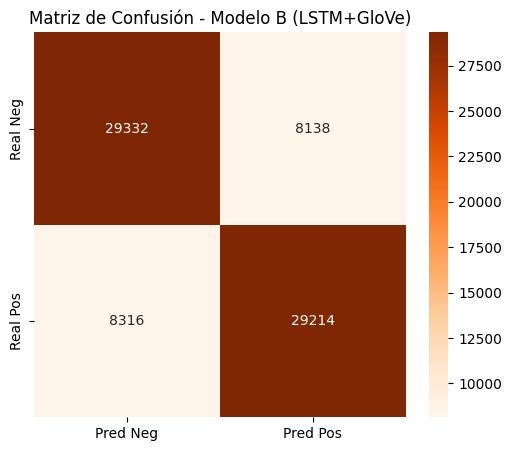

In [13]:
# Evaluamos el modelo B sobre el conjunto de validación
y_pred_prob_b = model_b.predict(X_val)
y_pred_b = (y_pred_prob_b > 0.5).astype(int)

print("\n--- MÉTRICAS MODELO B (LSTM + GloVe) ---")
print(classification_report(y_val, y_pred_b, target_names=['Negativo', 'Positivo']))

# Calculamos y visualizamos la matriz de confusión para el modelo B
cm_b = confusion_matrix(y_val, y_pred_b)
plt.figure(figsize=(6,5))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred Neg', 'Pred Pos'],
            yticklabels=['Real Neg', 'Real Pos'])
plt.title('Matriz de Confusión - Modelo B (LSTM+GloVe)')
plt.show()


--- MÉTRICAS MODELO GRU (con Dropout) ---
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step

Reporte de clasificación:
              precision    recall  f1-score   support

Negativo (0)       0.77      0.80      0.78     37470
Positivo (1)       0.79      0.76      0.77     37530

    accuracy                           0.78     75000
   macro avg       0.78      0.78      0.78     75000
weighted avg       0.78      0.78      0.78     75000


Generando Matriz de Confusión...


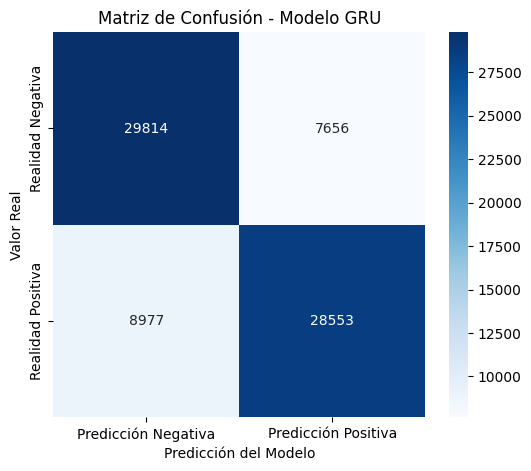

In [14]:
print("\n--- MÉTRICAS MODELO GRU (con Dropout) ---")

# Generamos predicciones en el set de validación para el modelo GRU
y_pred_prob = model_gru.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int)

# Imprimimos el reporte de clasificación (Precisión, Recall, F1-Score)
print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=['Negativo (0)', 'Positivo (1)']))

# Construimos y visualizamos la matriz de confusión para el modelo GRU
print("\nGenerando Matriz de Confusión...")
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicción Negativa', 'Predicción Positiva'],
            yticklabels=['Realidad Negativa', 'Realidad Positiva'])
plt.title('Matriz de Confusión - Modelo GRU')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

In [15]:
# Probamos el modelo GRU con nuevas oraciones
nuevas_oraciones = [
    "I really loved this trip!",
    "This was a terrible experience.",
    "My sister is afraid of going to the dentist.",
    "The food was okay, but the service was completely outstanding.",
    "I don't know why people like this movie, it is extremely boring."
]

# Convertimos las nuevas oraciones a secuencias y aplicamos padding
secuencias_nuevas = tokenizer.texts_to_sequences(nuevas_oraciones)
secuencias_padded = pad_sequences(secuencias_nuevas, maxlen=MAX_LEN, padding="post")

# Ejecutamos las predicciones finales con el modelo GRU
predicciones = model_gru.predict(secuencias_padded)

print("\nResultados de las nuevas predicciones:")
for i in range(len(nuevas_oraciones)):
    frase = nuevas_oraciones[i]
    probabilidad = predicciones[i][0]
    sentimiento = "Positivo 🟢" if probabilidad > 0.5 else "Negativo 🔴"
    print(f"Frase: '{frase}'\nSentimiento: {sentimiento} (Confianza: {probabilidad:.4f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

Resultados de las nuevas predicciones:
Frase: 'I really loved this trip!'
Sentimiento: Positivo 🟢 (Confianza: 0.5427)

Frase: 'This was a terrible experience.'
Sentimiento: Negativo 🔴 (Confianza: 0.0270)

Frase: 'My sister is afraid of going to the dentist.'
Sentimiento: Negativo 🔴 (Confianza: 0.0340)

Frase: 'The food was okay, but the service was completely outstanding.'
Sentimiento: Positivo 🟢 (Confianza: 0.6489)

Frase: 'I don't know why people like this movie, it is extremely boring.'
Sentimiento: Negativo 🔴 (Confianza: 0.0703)



1. **¿Qué diferencias observas entre el entrenamiento desde cero y el uso de embeddings preentrenados?**<br>
El modelo A alcanza rápidamente una alta exactitud en el conjunto de entrenamiento, de 86.1% en la época 5, pero su pérdida comienza a incrementar enseguida. Al contrario de este modelo, los que integran los embeddings de GloVe, como el modelo B y el GRU, crecen de forma simultánea, más estable entre validación y entrenamiento, lo que se parece más a un entorno real de aprendizaje.

2. **¿Cuál converge más rápido?**<br>
El modelo B converge más rápido hacia la estabilidad. Aunque el Modelo A muestra números más altos en las primeras épocas, comienza a bajar su validación. Los modelos preentrenados llegan a su punto máximo en 3 epocas y se mantiene sin descender.

3. **¿Cuál generaliza mejor (mejor desempeño en validación)?**<br>
Los modelos que se basan en Glove, el modelo B y el GRU, generalizan mejor. Casi no existe brecha entre el accuracy de entrenamiento, de 80% y el acuraccy de validación de 79.6%. Aunque el Modelo A tiene un accuracy de 80.9%, que es mayor, se observa que tiene tendencia al sobreajuste, lo que la hace menos confiable con datos reales.